# Supply Chain Disruption Prediction Using Machine Learning

This notebook builds a machine learning model to predict shipment disruption risk using supply chain data. It includes:
- data loading
- target definition
- preprocessing
- Logistic Regression and Random Forest models
- ROC-AUC evaluation
- feature importance analysis
- a simple decision-support layer


## 1. Import libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)


## 2. Load dataset

Update the filename below if your CSV is named differently.

In [2]:
DATA_FILE = 'DataCoSupplyChainDataset.csv'

print('Current directory contents:')
print(os.listdir())

df = pd.read_csv(DATA_FILE, encoding='latin1')
print(df.shape)
df.head()

Current directory contents:
['tokenized_access_logs.csv', 'Untitled.ipynb', 'DataCoSupplyChainDataset.csv', 'supply-chain-disruption-prediction', '.ipynb_checkpoints', 'supply_chain_disruption_prediction.ipynb', 'DescriptionDataCoSupplyChain.csv']
(180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

## 3. Define target

We use `Late_delivery_risk` as the binary target.

In [4]:
df['target_delay'] = df['Late_delivery_risk']
df['target_delay'].value_counts()

target_delay
1    98977
0    81542
Name: count, dtype: int64

## 4. Select pre-shipment features only

These were chosen to avoid leakage from post-outcome variables.

In [5]:
features = [
    'Type',
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer',
    'Category Name',
    'Customer Country',
    'Customer Segment',
    'Market',
    'Order Region',
    'Shipping Mode',
    'Order Item Quantity',
    'Order Item Total',
    'Product Price'
]

df_model = df[features + ['target_delay']].copy()
df_model.head()

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Category Name,Customer Country,Customer Segment,Market,Order Region,Shipping Mode,Order Item Quantity,Order Item Total,Product Price,target_delay
0,DEBIT,4,91.250000,314.640015,Sporting Goods,Puerto Rico,Consumer,Pacific Asia,Southeast Asia,Standard Class,1,314.640015,327.75,0
1,TRANSFER,4,-249.089996,311.359985,Sporting Goods,Puerto Rico,Consumer,Pacific Asia,South Asia,Standard Class,1,311.359985,327.75,1
2,CASH,4,-247.779999,309.720001,Sporting Goods,EE. UU.,Consumer,Pacific Asia,South Asia,Standard Class,1,309.720001,327.75,0
3,DEBIT,4,22.860001,304.809998,Sporting Goods,EE. UU.,Home Office,Pacific Asia,Oceania,Standard Class,1,304.809998,327.75,0
4,PAYMENT,4,134.210007,298.250000,Sporting Goods,Puerto Rico,Corporate,Pacific Asia,Oceania,Standard Class,1,298.250000,327.75,0


## 5. Clean and encode

In [6]:
# Fill missing values
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = df_model[col].fillna(df_model[col].mode()[0])
    else:
        df_model[col] = df_model[col].fillna(df_model[col].median())

# Encode categorical variables
label_encoders = {}

for col in df_model.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

df_model.head()

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Category Name,Customer Country,Customer Segment,Market,Order Region,Shipping Mode,Order Item Quantity,Order Item Total,Product Price,target_delay
0,1,4,91.250000,314.640015,40,1,0,3,15,3,1,314.640015,327.75,0
1,3,4,-249.089996,311.359985,40,1,0,3,13,3,1,311.359985,327.75,1
2,0,4,-247.779999,309.720001,40,0,0,3,13,3,1,309.720001,327.75,0
3,1,4,22.860001,304.809998,40,0,2,3,11,3,1,304.809998,327.75,0
4,2,4,134.210007,298.250000,40,1,1,3,11,3,1,298.250000,327.75,0


## 6. Train-test split

In [7]:
X = df_model.drop('target_delay', axis=1)
y = df_model['target_delay']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((144415, 13), (36104, 13))

## 7. Logistic Regression

In [8]:
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_log))
print('Logistic Regression ROC-AUC:', roc_auc_score(y_test, y_prob_log))
print('\nClassification Report:\n', classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.6918900952803013
Logistic Regression ROC-AUC: 0.7267208058373977

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.82      0.71     16308
           1       0.80      0.59      0.68     19796

    accuracy                           0.69     36104
   macro avg       0.71      0.70      0.69     36104
weighted avg       0.72      0.69      0.69     36104



## 8. Random Forest

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Random Forest ROC-AUC:', roc_auc_score(y_test, y_prob_rf))
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.668180810990472
Random Forest ROC-AUC: 0.729850543113959

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.69      0.65     16308
           1       0.72      0.65      0.68     19796

    accuracy                           0.67     36104
   macro avg       0.67      0.67      0.67     36104
weighted avg       0.67      0.67      0.67     36104



## 9. Model comparison

In [10]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison

,Model,ROC-AUC
0,Logistic Regression,0.726721
1,Random Forest,0.729851


## 10. Random Forest confusion matrix

In [11]:
cm = confusion_matrix(y_test, y_pred_rf)
cm

array([[11278,  5030],
       [ 6950, 12846]])

## 11. ROC curve

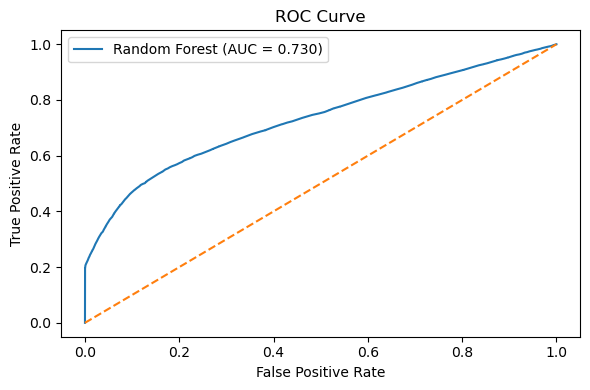

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_supply_chain.png', bbox_inches='tight')
plt.show()

## 12. Feature importance

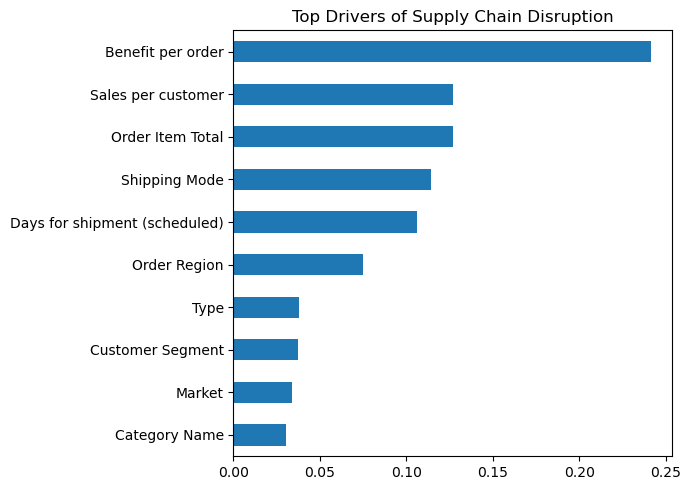

Benefit per order                0.241218
Sales per customer               0.127025
Order Item Total                 0.126971
Shipping Mode                    0.114403
Days for shipment (scheduled)    0.106284
Order Region                     0.074791
Type                             0.038019
Customer Segment                 0.037125
Market                           0.033920
Category Name                    0.030652
dtype: float64

In [13]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(7, 5))
feature_importance.head(10).sort_values().plot(kind='barh')
plt.title('Top Drivers of Supply Chain Disruption')
plt.tight_layout()
plt.savefig('feature_importance_supply_chain.png', bbox_inches='tight')
plt.show()

feature_importance.head(10)

## 13. Decision-support layer

In [14]:
results = X_test.copy()
results['actual_delay'] = y_test.values
results['delay_risk_score'] = y_prob_rf

def recommend_action(prob):
    if prob >= 0.75:
        return 'Reroute or expedite shipment'
    elif prob >= 0.50:
        return 'Monitor and prepare contingency'
    else:
        return 'Proceed as planned'

results['recommendation'] = results['delay_risk_score'].apply(recommend_action)
results[['delay_risk_score', 'recommendation']].head(10)

,delay_risk_score,recommendation
75083,0.545,Monitor and prepare contingency
88208,0.665,Monitor and prepare contingency
161090,0.160,Proceed as planned
151346,0.425,Proceed as planned
104796,0.790,Reroute or expedite shipment
133701,0.215,Proceed as planned
151705,0.980,Reroute or expedite shipment
76168,0.700,Monitor and prepare contingency
147381,1.000,Reroute or expedite shipment
3519,0.905,Reroute or expedite shipment


## 14. Conclusion

This project demonstrates a realistic machine learning approach to disruption prediction under uncertainty. By limiting features to pre-shipment variables, the notebook avoids leakage and better reflects real-world logistics decision-making.